Phân tích cảm xúc văn bản tiếng việt với DeepLearning

Cài đặt và import thư viện

In [1]:
!pip install pyvi

import os, re, json, unicodedata, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from typing import Set, List
import time

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Sklearn
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from collections import Counter
from pyvi import ViTokenizer
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00
Using device: cuda


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load data

In [7]:
df=pd.read_csv('/content/drive/MyDrive/data/data.csv', encoding='utf-8')
print("Data shape:", df.shape)
print(df.head())
print(df.info())

Data shape: (31460, 4)
                       comment label  rate Unnamed: 3
0               Áo bao đẹp ạ!!   POS     5        NaN
1                  Tuyệt vời !   POS     5        NaN
2   2day ao khong giong trong.   NEG     1        NaN
3  Mùi thơm,bôi lên da mềm da.   POS     5        NaN
4            Vải đẹp, dày dặn.   POS     5        NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31460 entries, 0 to 31459
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   comment     31460 non-null  object
 1   label       31460 non-null  object
 2   rate        31460 non-null  int64 
 3   Unnamed: 3  23 non-null     object
dtypes: int64(1), object(3)
memory usage: 983.3+ KB
None


Cách hàm xử lý teencode/emoji/number

In [8]:
URL_RE     = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
USER_RE    = re.compile(r'@[A-Za-z0-9_]+')
EMAIL_RE   = re.compile(r'\b[\w.+-]+@[\w-]+\.[\w.-]+\b')
PHONE_RE   = re.compile(r'\b(?:\+?84|0)(?:[1-9]\d){8,10}\b')
MONEY_RE   = re.compile(r'(\d+[.,]?\d*)\s?(k|nghìn|ngan|ngàn|tr|triệu|m|đ|vnd)\b', re.IGNORECASE)
PERCENT_RE = re.compile(r'\b\d+[.,]?\d*\s?%\b')
NUMBER_RE  = re.compile(r'\b\d+[.,]?\d*\b')

ZW_NBSP_RE = re.compile(r'[\u200b\xa0]')
MULTI_SPACE= re.compile(r'\s+')
REPEAT_CHAR= re.compile(r'(.)\1{2,}', re.DOTALL)

#Emoji
EMOJI_ALL_RE = re.compile(
    "["
    + "\U0001F600-\U0001F64F"  # Emoticons
    + "\U0001F300-\U0001F5FF"  # Symbols & Pictographs
    + "\U0001F680-\U0001F6FF"  # Transport & Map
    + "\U0001F1E0-\U0001F1FF"  # Flags
    + "\U00002702-\U000027B0"  # Dingbats
    + "\U000024C2-\U0001F251"  # Enclosed
    + "\U0001F926-\U0001F937"
    + "\U00010000-\U0010FFFF"  # Plane 1+
    + "\u200d" + "\u2640-\u2642" + "\u2600-\u2B55" + "\u23cf" + "\u23e9" + "\u231a" + "\u3030" + "\ufe0f"
    + "]",
    re.UNICODE
)

VS16_RE      = re.compile("\ufe0f")
SKIN_TONE_RE = re.compile("[" + "\U0001F3FB-\U0001F3FF" + "]")
ZWJ_RE       = re.compile("\u200d")

LAUGH_RE = re.compile(r"(=+\)+|\)+\)+|ha(?:ha)+|hi(?:hi)+|kkk+|hu+hu+|h(?:ì|í)+h(?:ì|í)+)", re.IGNORECASE)
EMO_POS_RE = re.compile(
    r"("
    r"[" r"\U0001F600-\U0001F606" r"\U0001F60A" r"\U0001F60D" r"\U0001F642" r"\U0001F929" r"\U0001F970" r"\U0001F618" r"\u263A" r"]"
    r"|(?:\u2764\ufe0f|\u2764)"
    r"|\U0001F44D|\U0001F44C"
    r"|:D|:d|:\)+|\^\^|=+\)+|:v"
    r")",
    re.UNICODE
)
EMO_NEG_RE = re.compile(
    r"("
    r"[" r"\U0001F61E" r"\U0001F61F" r"\U0001F620" r"\U0001F621" r"\U0001F622" r"\U0001F62D" r"\U0001F494" r"\U0001F641" r"\u2639" r"]"
    r"|\U0001F44E|:\(|=\(+|T_T|>\\.<"
    r")",
    re.UNICODE
)
EMO_NEU_RE = re.compile(r"[" r"\U0001F610" r"\U0001F611" r"\U0001F636" r"\U0001F914" r"\U0001F644" r"]", re.UNICODE)

PUNCT_KEEP = "!?…"
PUNCT_RE   = re.compile(rf"[^\w\s{PUNCT_KEEP}]")
EXCLAM_RE  = re.compile(r"!{2,}")
QUEST_RE   = re.compile(r"\?{2,}")

NEGS = {"không", "chẳng", "chả", "ko", "kh"}

#Teencode
def load_teencode_regex_list(path="/content/drive/MyDrive/data/teencode.txt"):
    pairs = []
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            for ln in f.read().splitlines():
                if not ln.strip(): continue
                parts = ln.split("\t")
                if len(parts) >= 2:
                    src, dst = parts[0].strip(), parts[1].strip()
                    if src:
                        pairs.append((re.compile(rf"\b{re.escape(src)}\b", re.IGNORECASE), dst))
    else:
        fallback = {
            "ko":"không","k":"không","kh":"không","hok":"không","hong":"không","hk":"không",
            "dc":"được","đc":"được","ms":"mới","ng":"người","trc":"trước","mik":"mình","vs":"với",
            "thik":"thích","bt":"bình_thường","ntn":"như_thế_nào","sp":"sản_phẩm","ok":"okay","oke":"okay",
            "vl":"rất","vkl":"rất"
        }
        for src, dst in fallback.items():
            pairs.append((re.compile(rf"\b{re.escape(src)}\b", re.IGNORECASE), dst))
    return pairs

TEENCODE_REGEX = load_teencode_regex_list("teencode.txt")

#Stopwords
def load_stopwords(path: str = "/content/drive/MyDrive/data/vietnamese_stopwords.txt") -> Set[str]:
    """Load stopwords from file, fallback to minimal set"""
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return set(line.strip() for line in f if line.strip())
    else:
        return {
            'thì', 'là', 'mà', 'có', 'với', 'được', 'này', 'kia', 'ấy', 'vậy',
            'về', 'nên', 'sẽ', 'đã', 'cũng', 'vẫn', 'vào', 'ra', 'lên', 'xuống',
            'nào', 'ai', 'gì', 'nơi', 'hãy', 'đừng', 'chớ', 'rất', 'quá', 'lắm'
        }

STOPWORDS = load_stopwords()

# Helpers
def _nfc(s: str) -> str:
    return unicodedata.normalize("NFC", str(s))

def _squash_repeats(s: str) -> str:
    return REPEAT_CHAR.sub(r"\1\1", s)

def _replace_special_tokens(s: str) -> str:
    s = URL_RE.sub(' __url__ ', s)
    s = EMAIL_RE.sub(' __email__ ', s)
    s = PHONE_RE.sub(' __phone__ ', s)
    s = PERCENT_RE.sub(' __percent__ ', s)
    s = MONEY_RE.sub(' __money__ ', s)
    s = NUMBER_RE.sub(' __num__ ', s)
    s = USER_RE.sub(' __user__ ', s)
    return s

def _apply_teencode(s: str) -> str:
    for rgx, rep in TEENCODE_REGEX:
        s = rgx.sub(rep, s)
    return s

def _tag_emojis(s: str) -> str:
    t = normalize_emoji_variants(s)
    t = LAUGH_RE.sub(" __laugh__ ", t)
    t = EMO_POS_RE.sub(" __emo_pos__ ", t)
    t = EMO_NEG_RE.sub(" __emo_neg__ ", t)
    t = EMO_NEU_RE.sub(" __emo_neu__ ", t)
    return t

def normalize_emoji_variants(s: str) -> str:
    s = VS16_RE.sub("", s)
    s = SKIN_TONE_RE.sub("", s)
    s = ZWJ_RE.sub("", s)
    return s

def join_negation(text: str, window: int = 1) -> str:
    toks, out, i = text.split(), [], 0
    bad = {"__emo_pos__","__emo_neg__","__url__","__email__","__percent__","__money__","__num__","__user__"}
    while i < len(toks):
        w = toks[i]
        if w in NEGS and i + 1 < len(toks):
            nxt = toks[i+1]
            if nxt not in bad and not any(ch in nxt for ch in "!?."):
                out.append(w + "_" + nxt)
                i += 2
                continue
        out.append(w); i += 1
    return " ".join(out)

def _remove_stopwords(tokens: List[str]) -> List[str]:
    """Remove stopwords while preserving special tokens"""
    return [t for t in tokens if t not in STOPWORDS or t.startswith('__')]

# Hàm chuẩn hóa
def normalize_text(
    s: str,
    keep_all_emojis: bool = False,
    use_vitok: bool = True,
    remove_stopwords_flag: bool = False
) -> str:
    s = _nfc(s)
    s = ZW_NBSP_RE.sub(' ', s)
    s = _replace_special_tokens(s)
    s = _squash_repeats(s)

    # 2) Teencode & Emoji
    s = _apply_teencode(s)
    s = _tag_emojis(s)

    # 3) Lowercase + tokenize
    s = s.lower().strip()
    if use_vitok:
        s = ViTokenizer.tokenize(s)  # Sử dụng pyvi để tokenize
    else:
        s = " ".join(s.split())

    # 4) Punctuation handling
    s = EXCLAM_RE.sub(" __exclam__ ", s)
    s = QUEST_RE.sub(" __quest__ ", s)
    s = s.replace("...", " __ellips__ ")
    s = PUNCT_RE.sub(" ", s)
    s = MULTI_SPACE.sub(' ', s).strip()

    # 5) Nối với các từ tiêu cực
    s = join_negation(s, window=1)

    # 6) Stopword removal
    if remove_stopwords_flag:
        tokens = s.split()
        tokens = _remove_stopwords(tokens)
        s = " ".join(tokens)

    # 7) Xóa emoji
    if not keep_all_emojis:
        s = EMOJI_ALL_RE.sub(" ", s)
        s = MULTI_SPACE.sub(' ', s).strip()

    return s

if __name__ == "__main__":
    # Test cases
    test_cases = [
        "Ko thích lắm đâu ^^ nhưng SP này 1tr5 ok phết!!! Link: https://abc.vn ❤️",
        "Tôi rất thích sản phẩm này nhưng mà giá hơi cao",
        "Cái này đẹp quá!!! Tôi muốn mua ngay lập tức 😍",
    ]

    for txt in test_cases:
        print(f"Original: {txt}")
        print(f"Normalized: {normalize_text(txt, remove_stopwords_flag=True)}")
        print("-" * 50)

Original: Ko thích lắm đâu ^^ nhưng SP này 1tr5 ok phết!!! Link: https://abc.vn ❤️
Normalized: không_thích đâu __emo_pos__ nhưng sản_phẩm 1tr5 okay phết ! ! link __url__ __emo_pos__
--------------------------------------------------
Original: Tôi rất thích sản phẩm này nhưng mà giá hơi cao
Normalized: tôi thích sản_phẩm nhưng giá hơi cao
--------------------------------------------------
Original: Cái này đẹp quá!!! Tôi muốn mua ngay lập tức 😍
Normalized: cái đẹp ! ! tôi muốn mua ngay lập_tức __emo_pos__
--------------------------------------------------


Tiền xử lý dữ liệu

In [9]:
# Cột văn bản và nhãn
TEXT_COL_RAW = "comment"
LABEL_COL_RAW = "label"

# Chuẩn hoá toàn bộ
df["text_norm"] = df[TEXT_COL_RAW].astype(str).map(lambda x: normalize_text(x))

# Gán nhãn id theo thứ tự neg/neu/pos
DEFAULT_LABELS = ["neg","neu","pos"]
def build_label_mapping(series):
    uniq = sorted(series.astype(str).str.lower().unique())
    ordered = [x for x in DEFAULT_LABELS if x in uniq] + [x for x in uniq if x not in DEFAULT_LABELS]
    id2label = {i: lab for i, lab in enumerate(ordered)}
    label2id = {lab: i for i, lab in id2label.items()}
    return label2id, id2label

label2id, id2label = build_label_mapping(df[LABEL_COL_RAW])
df["label_id"] = df[LABEL_COL_RAW].astype(str).str.lower().map(label2id)
LABEL_COL = "label_id"
num_labels = len(id2label)
print("Labels:", id2label)

print("Data counts:", df['label_id'].value_counts().sort_index().to_dict())

Labels: {0: 'neg', 1: 'neu', 2: 'pos'}
Data counts: {0: 6669, 1: 4698, 2: 20093}


Chia train/val/test

In [10]:
TEXT_COL  = "text_norm"
LABEL_COL = "label_id"

tr_df, tmp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label_id"])
va_df, test_df = train_test_split(tmp_df, test_size=0.5, random_state=42, stratify=tmp_df["label_id"])

print(f"Tổng số mẫu: {len(df)}")
print(f"Số mẫu tập Huấn luyện: {len(tr_df)}")
print(f"Số mẫu tập Kiểm định (Validation): {len(va_df)}")
print(f"Số mẫu tập Kiểm tra (Test): {len(test_df)}")

# Kiểm tra các class sau cân bằng
print("Training class distribution:")
print(tr_df[LABEL_COL].value_counts())

print("Validation class distribution:")
print(va_df[LABEL_COL].value_counts())

Tổng số mẫu: 31460
Số mẫu tập Huấn luyện: 25168
Số mẫu tập Kiểm định (Validation): 3146
Số mẫu tập Kiểm tra (Test): 3146
Training class distribution:
label_id
2    16074
0     5335
1     3759
Name: count, dtype: int64
Validation class distribution:
label_id
2    2009
0     667
1     470
Name: count, dtype: int64


Vocab, mã hoá và padding

Đề xuất MAX_LEN (p95, train-split): 22


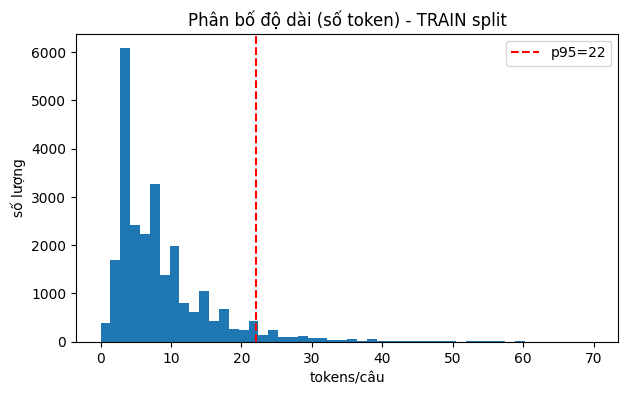

Vocab size (từ TRAIN split): 3697


In [11]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

def length_percentile(texts, p=95, lo=16, hi=256):
    lengths = [len(str(t).split()) for t in texts]
    perc = int(np.percentile(lengths, p))
    # Giới hạn để tránh quá nhỏ/quá lớn
    return max(lo, min(hi, perc)), lengths

def build_vocab_from_texts(texts, min_freq=2, max_vocab_size=None):
    counter = Counter()
    for s in texts:
        counter.update(str(s).split())
    # Lọc theo min_freq
    items = [(w,f) for w,f in counter.items() if f >= min_freq]
    # Sắp xếp ổn định: tần suất
    items.sort(key=lambda x: (-x[1], x[0]))
    # Giới hạn
    if max_vocab_size is not None:
        items = items[:max_vocab_size]
    stoi = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for w,_ in items:
        if w not in stoi:
            stoi[w] = len(stoi)
    itos = {i:w for w,i in stoi.items()}
    return stoi, itos

def encode_line(s, stoi, max_len):
    pad_id = stoi[PAD_TOKEN]
    unk_id = stoi[UNK_TOKEN]
    toks = str(s).split()
    ids = [stoi.get(t, unk_id) for t in toks]
    ids = (ids + [pad_id] * max(0, max_len - len(ids)))[:max_len]
    return ids

def encode_series(series, stoi, max_len):
    return [encode_line(s, stoi, max_len) for s in series.astype(str).tolist()]

MAX_LEN, _lengths = length_percentile(tr_df[TEXT_COL], p=95)
print("Đề xuất MAX_LEN (p95, train-split):", MAX_LEN)

plt.figure(figsize=(7,4))
plt.hist(_lengths, bins=50)
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'p95={MAX_LEN}')
plt.title('Phân bố độ dài (số token) - TRAIN split')
plt.xlabel('tokens/câu'); plt.ylabel('số lượng'); plt.legend(); plt.show()

stoi, itos = build_vocab_from_texts(tr_df[TEXT_COL], min_freq=2)
print("Vocab size (từ TRAIN split):", len(stoi))

In [9]:
df['text_len'] = df['text_norm'].str.split().str.len()
print(df['text_len'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

count    31460.000000
mean         8.603560
std          7.113663
min          0.000000
50%          6.000000
90%         17.000000
95%         22.000000
99%         36.000000
max         77.000000
Name: text_len, dtype: float64


In [12]:
MAX_LEN = 40
# Encode
tr_df["input_ids"] = encode_series(tr_df[TEXT_COL], stoi, MAX_LEN)
va_df["input_ids"] = encode_series(va_df[TEXT_COL], stoi, MAX_LEN)
test_df["input_ids"] = encode_series(test_df[TEXT_COL], stoi, MAX_LEN)

pad_id  = stoi["<PAD>"]

Loading dataset

In [13]:
class TextClsDataset(Dataset):
    def __init__(self, df, x_col="input_ids", y_col=LABEL_COL):
        df = df.reset_index(drop=True)
        self.x = df[x_col].tolist()
        self.y = df[y_col].astype(int).tolist()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        ids = torch.tensor(self.x[idx], dtype=torch.long)
        y   = torch.tensor(self.y[idx], dtype=torch.long)
        return ids, y

train_ds = TextClsDataset(tr_df, x_col="input_ids", y_col=LABEL_COL)
val_ds   = TextClsDataset(va_df, x_col="input_ids", y_col=LABEL_COL)
test_ds  = TextClsDataset(test_df, x_col="input_ids", y_col=LABEL_COL)

# Loader ổn định
BATCH_SIZE  = 64
NUM_WORKERS = 0
PIN_MEMORY  = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)


Xây dựng mô hình GRU và LSTM

In [14]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, num_labels, embed_dim=128, hidden_size=128,
                 num_layers=1, dropout=0.5, rnn_type="lstm", pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embed_dropout = nn.Dropout(dropout)
        self.rnn_type  = rnn_type.lower()
        rnn_cls = nn.LSTM if self.rnn_type == "lstm" else nn.GRU
        self.rnn = rnn_cls(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.fc1 = nn.Linear(hidden_size * 2, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc_out = nn.Linear(128, num_labels)
        self.fc_dropout = nn.Dropout(dropout)

    def forward(self, x, pad_id=0):
        """
        x: [B, T]
        """
        mask = (x != pad_id).float()
        emb  = self.embedding(x)
        emb  = self.embed_dropout(emb)
        out, _ = self.rnn(emb)

        # Masked mean pooling
        mask_exp = mask.unsqueeze(-1)
        out = out * mask_exp
        sum_out = out.sum(dim=1)
        len_real = mask.sum(dim=1).clamp(min=1)
        mean_out = sum_out / len_real.unsqueeze(-1)

        # SỬ DỤNG CÁC LỚP MỚI VÀ HÀM KÍCH HOẠT RELU
        # Áp dụng dropout và hàm kích hoạt ReLU giữa các lớp
        x = self.fc_dropout(mean_out)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        logits = self.fc_out(x)

        return logits

Train và đánh giá

In [15]:
classes = np.array(sorted(tr_df[LABEL_COL].unique()))
weights = compute_class_weight(class_weight="balanced", classes=classes, y=tr_df[LABEL_COL].values)
weights = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=weights)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    all_preds, all_labels = [], []
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(xb, pad_id)
            loss   = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        labels = yb.detach().cpu().numpy()
        all_preds.extend(preds); all_labels.extend(labels)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1, all_preds, all_labels

def train_model(rnn_type="lstm", epochs=100, lr=1e-3, embed_dim=128, hidden_size=128, num_layers=1, dropout=0.5, weight_decay=1e-4, patience=5):
    vocab_size = len(stoi)
    num_labels = 3
    model = RNNClassifier(
        vocab_size=vocab_size, num_labels=num_labels,
        embed_dim=embed_dim, hidden_size=hidden_size,
        num_layers=num_layers, dropout=dropout,
        rnn_type=rnn_type, pad_idx=pad_id
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2
    )
    best_f1, best_state, wait = -1.0, None, 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s = [], []

    for ep in range(1, epochs+1):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, train_loader, optimizer)
        va_loss, va_acc, va_f1, _, _ = run_epoch(model, val_loader, optimizer=None)
        print(f"[{rnn_type.upper()}][Epoch {ep:02d}] "
              f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f} | "
              f"val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")

        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        train_accs.append(tr_acc)
        val_accs.append(va_acc)
        train_f1s.append(tr_f1)
        val_f1s.append(va_f1)

        scheduler.step(va_f1)

        # EarlyStopping theo F1 val
        if va_f1 > best_f1:
            best_f1, best_state, wait = va_f1, model.state_dict(), 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping (no val F1 improvement for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Biểu đồ Loss
    plt.figure(figsize=(6, 4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

    # Biểu đồ F1 Score
    plt.figure(figsize=(6, 4))
    plt.plot(train_f1s, label='Train F1')
    plt.plot(val_f1s, label='Val F1')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.title('Training and Validation F1 Score')
    plt.show()

    # Biểu đồ Accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.show()

    # Đánh giá trên test và vẽ Confusion Matrix
    te_loss, te_acc, te_f1, te_preds, te_labels = run_epoch(model, test_loader, optimizer=None)
    print(f"[{rnn_type.upper()}][TEST]  loss={te_loss:.4f} acc={te_acc:.4f} f1={te_f1:.4f}")

    # Vẽ Confusion Matrix
    cm = confusion_matrix(te_labels, te_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[id2label[i] for i in range(num_labels)],
                yticklabels=[id2label[i] for i in range(num_labels)])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix ({rnn_type.upper()} on Test Set)')
    plt.show()

    return model


Huấn luyện mô hình

Training LSTM model...
[LSTM][Epoch 01] train_loss=0.8615 acc=0.6333 f1=0.5458 | val_loss=0.7487 acc=0.7444 f1=0.6227
[LSTM][Epoch 02] train_loss=0.7650 acc=0.7054 f1=0.6193 | val_loss=0.7192 acc=0.7498 f1=0.6592
[LSTM][Epoch 03] train_loss=0.7318 acc=0.7235 f1=0.6395 | val_loss=0.7188 acc=0.7730 f1=0.6692
[LSTM][Epoch 04] train_loss=0.7093 acc=0.7310 f1=0.6534 | val_loss=0.7163 acc=0.7635 f1=0.6637
[LSTM][Epoch 05] train_loss=0.6875 acc=0.7349 f1=0.6605 | val_loss=0.7048 acc=0.7702 f1=0.6763
[LSTM][Epoch 06] train_loss=0.6735 acc=0.7382 f1=0.6685 | val_loss=0.6925 acc=0.7756 f1=0.6689
[LSTM][Epoch 07] train_loss=0.6666 acc=0.7470 f1=0.6744 | val_loss=0.6926 acc=0.7537 f1=0.6736
[LSTM][Epoch 08] train_loss=0.6480 acc=0.7525 f1=0.6841 | val_loss=0.7203 acc=0.7788 f1=0.6769
[LSTM][Epoch 09] train_loss=0.6434 acc=0.7552 f1=0.6872 | val_loss=0.7385 acc=0.7695 f1=0.6749
[LSTM][Epoch 10] train_loss=0.6250 acc=0.7604 f1=0.6945 | val_loss=0.7103 acc=0.7568 f1=0.6764
[LSTM][Epoch 11] train_loss

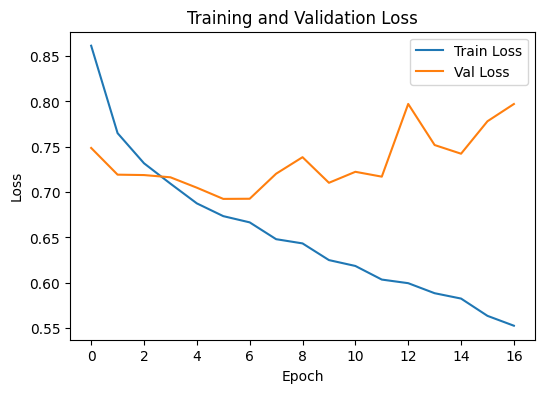

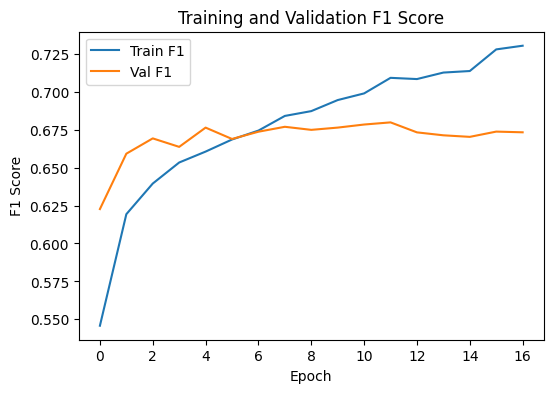

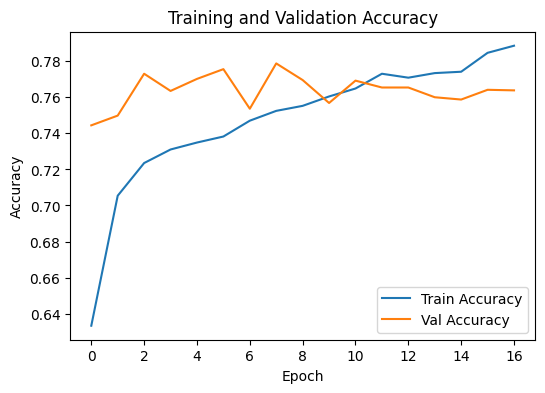

[LSTM][TEST]  loss=0.7746 acc=0.7635 f1=0.6710


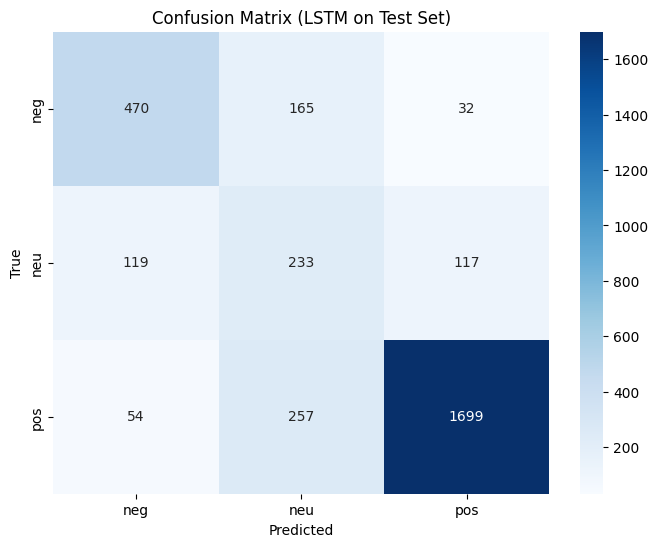

LSTM training time: 44.86 seconds

Training GRU model...
[GRU][Epoch 01] train_loss=0.8628 acc=0.6474 f1=0.5549 | val_loss=0.7739 acc=0.7505 f1=0.6380
[GRU][Epoch 02] train_loss=0.7745 acc=0.6986 f1=0.6101 | val_loss=0.7237 acc=0.7502 f1=0.6575
[GRU][Epoch 03] train_loss=0.7374 acc=0.7181 f1=0.6349 | val_loss=0.7103 acc=0.7727 f1=0.6718
[GRU][Epoch 04] train_loss=0.7115 acc=0.7242 f1=0.6456 | val_loss=0.7181 acc=0.7581 f1=0.6657
[GRU][Epoch 05] train_loss=0.6974 acc=0.7355 f1=0.6570 | val_loss=0.7027 acc=0.7559 f1=0.6684
[GRU][Epoch 06] train_loss=0.6821 acc=0.7373 f1=0.6627 | val_loss=0.6968 acc=0.7305 f1=0.6603
[GRU][Epoch 07] train_loss=0.6554 acc=0.7501 f1=0.6809 | val_loss=0.7124 acc=0.7651 f1=0.6724
[GRU][Epoch 08] train_loss=0.6504 acc=0.7500 f1=0.6816 | val_loss=0.7218 acc=0.7686 f1=0.6755
[GRU][Epoch 09] train_loss=0.6356 acc=0.7543 f1=0.6863 | val_loss=0.7034 acc=0.7711 f1=0.6781
[GRU][Epoch 10] train_loss=0.6277 acc=0.7562 f1=0.6905 | val_loss=0.6969 acc=0.7699 f1=0.6785
[GR

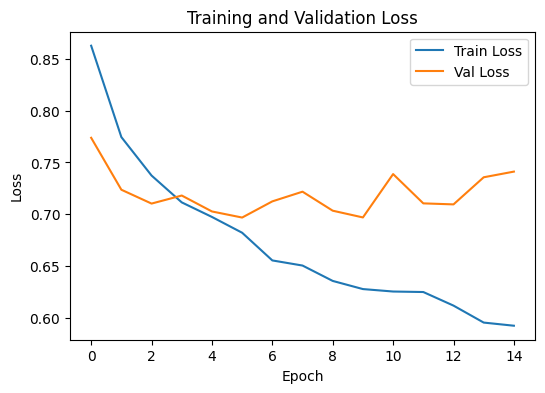

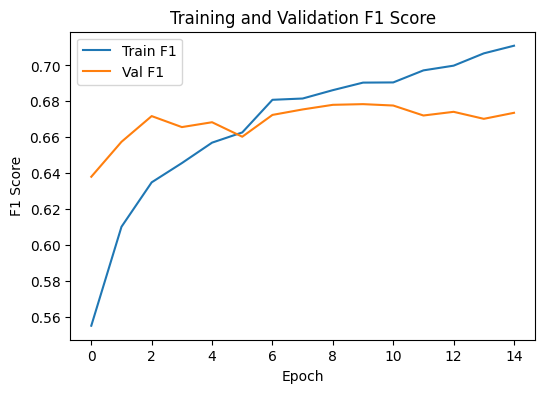

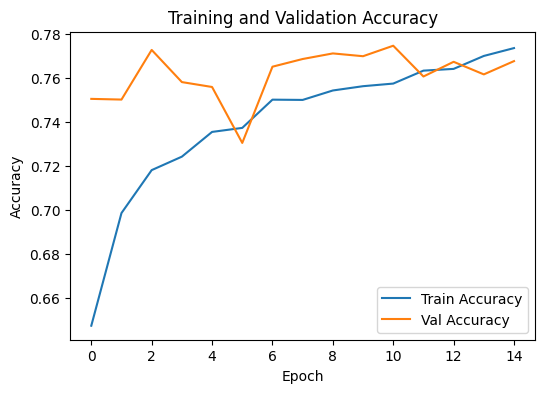

[GRU][TEST]  loss=0.7246 acc=0.7702 f1=0.6800


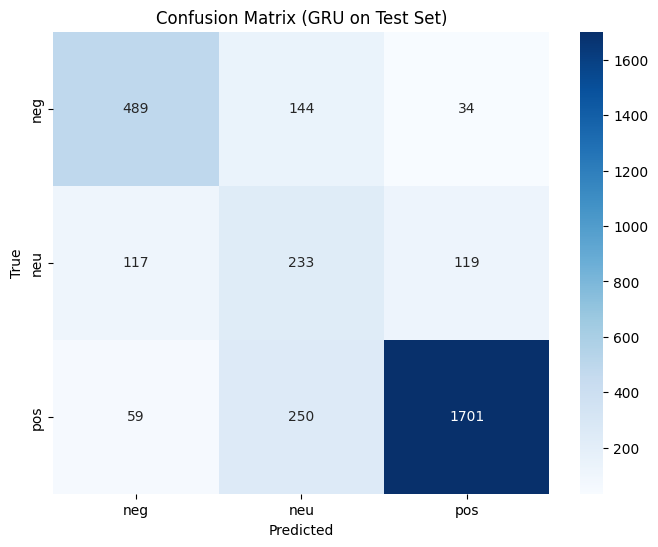

GRU training time: 32.31 seconds


In [16]:
print("Training LSTM model...")
start_time_lstm = time.time()
lstm_model = train_model(rnn_type="lstm")
end_time_lstm = time.time()
lstm_training_time = end_time_lstm - start_time_lstm
print(f"LSTM training time: {lstm_training_time:.2f} seconds")

print("\nTraining GRU model...")
start_time_gru = time.time()
gru_model = train_model(rnn_type="gru")
end_time_gru = time.time()
gru_training_time = end_time_gru - start_time_gru
print(f"GRU training time: {gru_training_time:.2f} seconds")

# Save models
torch.save(lstm_model.state_dict(), 'lstm_model.pth')
torch.save(gru_model.state_dict(), 'gru_model.pth')

Save vocabulary

In [20]:
vocab_data = {
    'stoi': stoi,
    'itos': itos,
    'max_len': MAX_LEN,
    'label2id': label2id,
    'id2label': id2label
}
with open('vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab_data, f, ensure_ascii=False, indent=2)

Dự đoán và đánh giá

In [18]:
def predict(model, raw_text: str, stoi=stoi, max_len=MAX_LEN):
    normalized = normalize_text(raw_text)
    ids = encode_line(normalized, stoi, max_len)
    x = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(x, pad_id)
        probs  = F.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
        pred   = int(probs.argmax())
    return id2label[pred], probs, normalized
test_texts = [
    "bài hát này hay quá, mình thích!",
    "mình không thích video này đâu",
    "sản phẩm tạm được, không có gì đặc biệt",
    "dịch vụ rất tệ, sẽ không quay lại nữa",
    "buồn"
]

print("\nTesting models with sample texts:")
for text in test_texts:
    lstm_pred, lstm_probs, norm_text = predict(lstm_model, text)
    gru_pred, gru_probs, _ = predict(gru_model, text)

    print(f"\nText: {text}")
    print(f"Normalized: {norm_text}")
    print(f"LSTM Prediction: {lstm_pred} (probs: {lstm_probs.round(3)})")
    print(f"GRU Prediction: {gru_pred} (probs: {gru_probs.round(3)})")

def evaluate_model(model, loader, criterion):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb, pad_id)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            preds = logits.argmax(dim=1).cpu().numpy()
            labels = yb.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"Test Loss: {avg_loss:.4f}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=[id2label[i] for i in range(len(id2label))]))

    return avg_loss, acc, f1

y_test = test_df[LABEL_COL].values
class_weights_test = compute_class_weight('balanced', classes=np.unique(y_test), y=y_test)
class_weights_test = torch.tensor(class_weights_test, dtype=torch.float).to(device)
criterion_test = nn.CrossEntropyLoss(weight=class_weights_test)

print("\nEvaluating LSTM model on test set:")
evaluate_model(lstm_model, test_loader, criterion_test)

print("\nEvaluating GRU model on test set:")
evaluate_model(gru_model, test_loader, criterion_test)


Testing models with sample texts:

Text: bài hát này hay quá, mình thích!
Normalized: bài hát này hay quá mình thích !
LSTM Prediction: pos (probs: [0.018 0.045 0.936])
GRU Prediction: pos (probs: [0.03  0.062 0.908])

Text: mình không thích video này đâu
Normalized: mình không_thích video này đâu
LSTM Prediction: neg (probs: [0.675 0.294 0.031])
GRU Prediction: neg (probs: [0.479 0.465 0.055])

Text: sản phẩm tạm được, không có gì đặc biệt
Normalized: sản_phẩm tạm được không_có gì đặc_biệt
LSTM Prediction: neu (probs: [0.383 0.518 0.099])
GRU Prediction: neu (probs: [0.143 0.732 0.125])

Text: dịch vụ rất tệ, sẽ không quay lại nữa
Normalized: dịch_vụ rất tệ sẽ không_quay lại nữa
LSTM Prediction: neg (probs: [0.997 0.001 0.002])
GRU Prediction: neg (probs: [0.982 0.005 0.014])

Text: buồn
Normalized: buồn
LSTM Prediction: neu (probs: [0.341 0.647 0.012])
GRU Prediction: neg (probs: [0.595 0.375 0.03 ])

Evaluating LSTM model on test set:
Test Loss: 0.7749
Test Accuracy: 0.7635
Test F1

(0.7248403636498278, 0.770184361093452, 0.6799504995315849)

Xuất tokenizer.json nhanh từ stoi

In [25]:
# export_tokenizer.py
import json
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from transformers import PreTrainedTokenizerFast

# Đọc stoi & special tokens
V = json.load(open("vocab.json","r",encoding="utf-8"))
stoi = V["stoi"]
pad_token = "<PAD>"
unk_token = "<UNK>"

# 1) Build WordLevel model với vocab hiện có
tok_model = WordLevel(vocab=stoi, unk_token=unk_token)
tokenizer = Tokenizer(tok_model)
tokenizer.pre_tokenizer = Whitespace()

# 2) Wrap sang PreTrainedTokenizerFast
fast_tok = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    unk_token=unk_token,
    pad_token=pad_token
)

save_dir = "models/vn-rnn"
fast_tok.save_pretrained(save_dir)

# Ghi special tokens map (để chắc chắn)
with open(f"{save_dir}/special_tokens_map.json","w",encoding="utf-8") as f:
    json.dump({"unk_token":unk_token,"pad_token":pad_token}, f, ensure_ascii=False, indent=2)



Tạo config.json

In [27]:
# export_config.py
import json

V = json.load(open("vocab.json","r",encoding="utf-8"))
stoi = V["stoi"]; id2label = {int(k):v for k,v in V["id2label"].items()}
label2id = V["label2id"]
pad_id = stoi["<PAD>"]

cfg = {
  "model_type": "rnncls",
  "vocab_size": len(stoi),
  "num_labels": len(id2label),
  "id2label": id2label,
  "label2id": label2id,
  "pad_token_id": pad_id,

  # tham số mô hình
  "embedding_dim": 128,
  "hidden_size": 128,
  "num_layers": 1,
  "dropout": 0.5,
  "bidirectional": True,
  "rnn_type": "gru",
  "max_position_embeddings": V["max_len"],
}

with open("models/vn-rnn/config.json","w",encoding="utf-8") as f:
    json.dump(cfg, f, ensure_ascii=False, indent=2)

# labels.txt (mỗi dòng 1 nhãn theo thứ tự id)
with open("models/vn-rnn/labels.txt","w",encoding="utf-8") as f:
    for i in range(len(id2label)):
        f.write(id2label[i]+"\n")


Lưu lstm_model.bin

In [28]:
# export_weights.py
import os, json, torch

#Đường dẫn
SAVE_DIR = "models/vn-rnn"                 # thư mục model HF
CKPT     = "gru_model.pth"
OUT_BIN  = os.path.join(SAVE_DIR, "gru_model.bin")  # tên file HF chuẩn

#kiểm tra config.json khớp tham số đã train
cfg = json.load(open(os.path.join(SAVE_DIR, "config.json"), "r", encoding="utf-8"))
cfg.setdefault("rnn_type", "gru")
cfg.setdefault("bidirectional", True)

with open(os.path.join(SAVE_DIR, "config.json"), "w", encoding="utf-8") as f:
    json.dump(cfg, f, ensure_ascii=False, indent=2)

# nạp checkpoint gốc
sd = torch.load(CKPT, map_location="cpu")

# Thêm prefix để khớp RNNForSequenceClassification
needs_prefix = not any(k.startswith("model.") for k in sd.keys())
if needs_prefix:
    sd = {f"model.{k}": v for k, v in sd.items()}

# Kiểm tra nhanh
if cfg.get("bidirectional", True):
    req = [
        "model.rnn.weight_ih_l0_reverse",
        "model.rnn.weight_hh_l0_reverse",
        "model.rnn.bias_ih_l0_reverse",
        "model.rnn.bias_hh_l0_reverse",
    ]
    missing_rev = [k for k in req if k not in sd]
    if missing_rev:
        print("[WARN] Config đang bidirectional=True nhưng ckpt thiếu tham số _reverse:")
        print("       ", missing_rev)
        print("       -> Nếu model của bạn thực sự 1 chiều, đổi bidirectional=False trong config.json")

#lưu đúng tên file HF
os.makedirs(SAVE_DIR, exist_ok=True)
torch.save(sd, OUT_BIN)
print(f"[OK] Saved HF state_dict to: {OUT_BIN}")

[OK] Saved HF state_dict to: models/vn-rnn/gru_model.bin


In [29]:
# 3) Nén thành .zip và tải về
!cd /content && zip -r models.zip models -q
from google.colab import files
files.download("/content/models.zip")

print("DONE → /content/models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DONE → /content/models.zip
